In [1]:
pip install yfinance

Maintenant, collections les données boursières de certaines entreprises indiennes populaires:

In [2]:
import yfinance as yf
import pandas as pd
from datetime import date, timedelta

In [3]:
# definir la periode de temps pour les données
end_date = date.today().strftime("%Y-%m-%d")
start_date = (date.today() - timedelta(days=365)).strftime("%Y-%m-%d")

In [21]:
# liste des symboles boursiers à telecharger
tickers = ['RELIANCE.NS', 'TCS.NS', 'INFY.NS', 'HDFCBANK.NS']
data = yf.download(tickers, start=start_date, end=end_date, progress=False)

/tmp/ipython-input-3264588839.py:3: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, progress=False)


In [8]:
print(data.columns)

MultiIndex([(  'Date',            ''),
            ( 'Close', 'HDFCBANK.NS'),
            ( 'Close',     'INFY.NS'),
            ( 'Close', 'RELIANCE.NS'),
            ( 'Close',      'TCS.NS'),
            (  'High', 'HDFCBANK.NS'),
            (  'High',     'INFY.NS'),
            (  'High', 'RELIANCE.NS'),
            (  'High',      'TCS.NS'),
            (   'Low', 'HDFCBANK.NS'),
            (   'Low',     'INFY.NS'),
            (   'Low', 'RELIANCE.NS'),
            (   'Low',      'TCS.NS'),
            (  'Open', 'HDFCBANK.NS'),
            (  'Open',     'INFY.NS'),
            (  'Open', 'RELIANCE.NS'),
            (  'Open',      'TCS.NS'),
            ('Volume', 'HDFCBANK.NS'),
            ('Volume',     'INFY.NS'),
            ('Volume', 'RELIANCE.NS'),
            ('Volume',      'TCS.NS')],
           names=['Price', 'Ticker'])


In [30]:
# Re-fetch the data to ensure a clean state
data = yf.download(tickers, start=start_date, end=end_date, progress=False)

# reset index
data = data.reset_index()
# Flatten the MultiIndex columns
data.columns = ['_'.join(col).strip('_') for col in data.columns]

# melt the dataframe
data_melted = data.melt(id_vars=['Date'], var_name='Attribute_Ticker', value_name='Price')
display(data_melted.head())

/tmp/ipython-input-2839807942.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start=start_date, end=end_date, progress=False)


,Date,Attribute_Ticker,Price
0,2024-08-19,Close_HDFCBANK.NS,1613.796509
1,2024-08-20,Close_HDFCBANK.NS,1619.879517
2,2024-08-21,Close_HDFCBANK.NS,1608.109131
3,2024-08-22,Close_HDFCBANK.NS,1613.549316
4,2024-08-23,Close_HDFCBANK.NS,1607.367310


In [34]:
# Split 'Attribute_Ticker' into 'Attribute' and 'Ticker'
data_melted[['Attribute', 'Ticker']] = data_melted['Attribute_Ticker'].str.split('_', expand=True)

# pivot the dataframe
data_pivoted = data_melted.pivot_table(index=['Date', 'Ticker'], columns='Attribute', values='Price', aggfunc='first')
display(data_pivoted.head())

Attribute                     Close         High          Low         Open  \
Date       Ticker                                                            
2024-08-19 HDFCBANK.NS  1613.796509  1619.830108  1606.031831  1619.830108   
           INFY.NS      1818.223633  1820.904947  1803.013173  1813.543473   
           RELIANCE.NS  1482.479126  1492.339768  1474.610528  1476.602572   
           TCS.NS       4414.077637  4418.255773  4316.112736  4346.244372   
2024-08-20 HDFCBANK.NS  1619.879517  1628.089249  1609.741051  1609.741051   

Attribute                   Volume  
Date       Ticker                   
2024-08-19 HDFCBANK.NS   9751082.0  
           INFY.NS       2585989.0  
           RELIANCE.NS  13797742.0  
           TCS.NS        2055210.0  
2024-08-20 HDFCBANK.NS  15567247.0

In [35]:
stock_data = data_pivoted.reset_index()

In [36]:
print(stock_data.head())

Attribute       Date       Ticker        Close         High          Low  \
0         2024-08-19  HDFCBANK.NS  1613.796509  1619.830108  1606.031831   
1         2024-08-19      INFY.NS  1818.223633  1820.904947  1803.013173   
2         2024-08-19  RELIANCE.NS  1482.479126  1492.339768  1474.610528   
3         2024-08-19       TCS.NS  4414.077637  4418.255773  4316.112736   
4         2024-08-20  HDFCBANK.NS  1619.879517  1628.089249  1609.741051   

Attribute         Open      Volume  
0          1619.830108   9751082.0  
1          1813.543473   2585989.0  
2          1476.602572  13797742.0  
3          4346.244372   2055210.0  
4          1609.741051  15567247.0  


Voyons maintenant la performance boursière de ces entreprises sur le marché boursier au fil du temps :

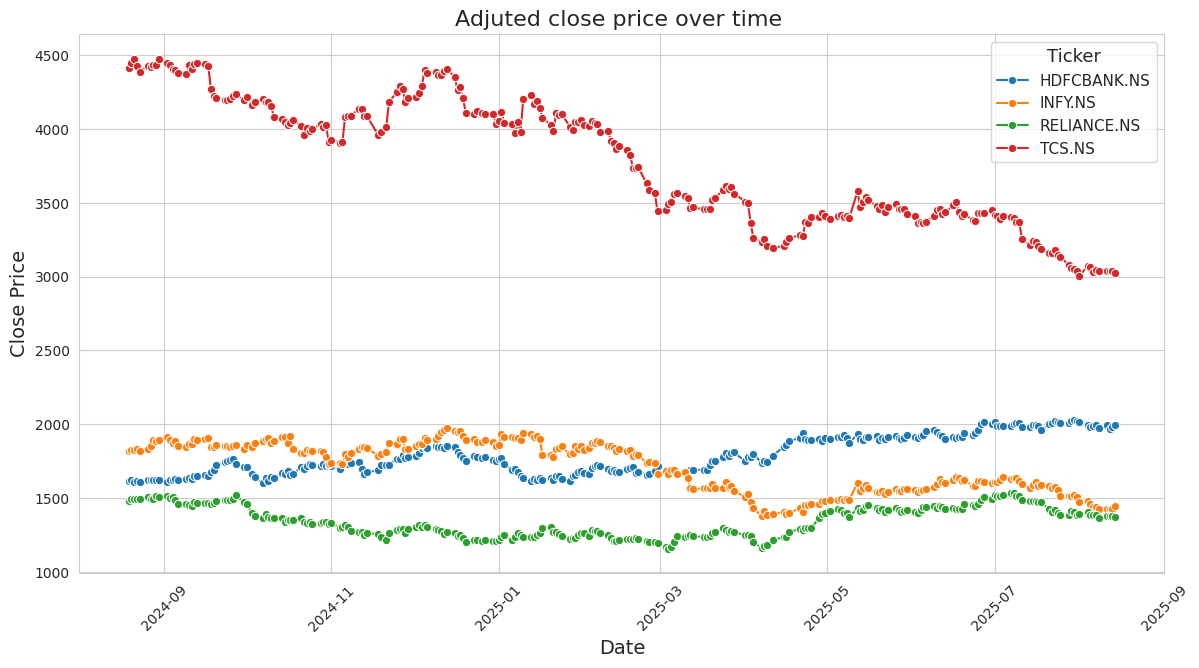

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns
stock_data['Date'] = pd.to_datetime(stock_data['Date'])
stock_data.set_index('Date', inplace=True)
stock_data.reset_index(inplace=True)
plt.figure(figsize=(14, 7))
sns.set_style('whitegrid')


sns.lineplot(data=stock_data, x='Date', y='Close', hue='Ticker', marker='o')

plt.title('Adjuted close price over time ', fontsize=16)
plt.xlabel('Date', fontsize=14)
plt.ylabel('Close Price', fontsize=14)
plt.legend(title='Ticker', title_fontsize='13', fontsize='11')
plt.grid(True)
plt.xticks(rotation=45)
plt.show()

1. Graphique : Adjusted close price over time

Ce que le graphique montre : Ce graphique en courbes affiche l'évolution du prix de clôture ajusté (qui prend en compte les divisions d'actions et les dividendes) de quatre actions indiennes (HDFCBANK.NS, INFY.NS, RELIANCE.NS, TCS.NS) sur une période d'un an. Chaque ligne colorée représente une action différente, et les points sur les lignes correspondent aux jours de bourse.

**Interprétation** :
Tendances générales : Vous pouvez observer les tendances à long terme de chaque action. Par exemple, HDFCBANK.NS semble avoir une tendance générale à la hausse sur la période, tandis que INFY.NS et TCS.NS montrent une tendance baissière notable après le début de l'année 2025. RELIANCE.NS semble plus volatile avec des hausses et des baisses plus prononcées.
Performance relative : Vous pouvez comparer la performance relative des actions. TCS.NS a le prix de clôture le plus élevé sur la majeure partie de la période, mais connaît une baisse significative. HDFCBANK.NS montre une croissance plus constante.
Volatilité : L'amplitude des fluctuations pour chaque ligne donne une indication de la volatilité de l'action. RELIANCE.NS et TCS.NS semblent présenter une volatilité plus élevée que HDFCBANK.NS et INFY.NS sur certaines périodes.
Événements marquants : Les changements soudains de direction dans les courbes peuvent correspondre à des événements spécifiques (annonces de résultats, nouvelles économiques, etc.) qui ont affecté le prix de l'action.
Points de données : La présence de points sur les lignes indique la disponibilité des données pour chaque jour de bourse.

Maintenant, calculons les moyennes mobiles sur 50 et 200 jours et représentons-les avec le prix de clôture ajusté pour chaque action :

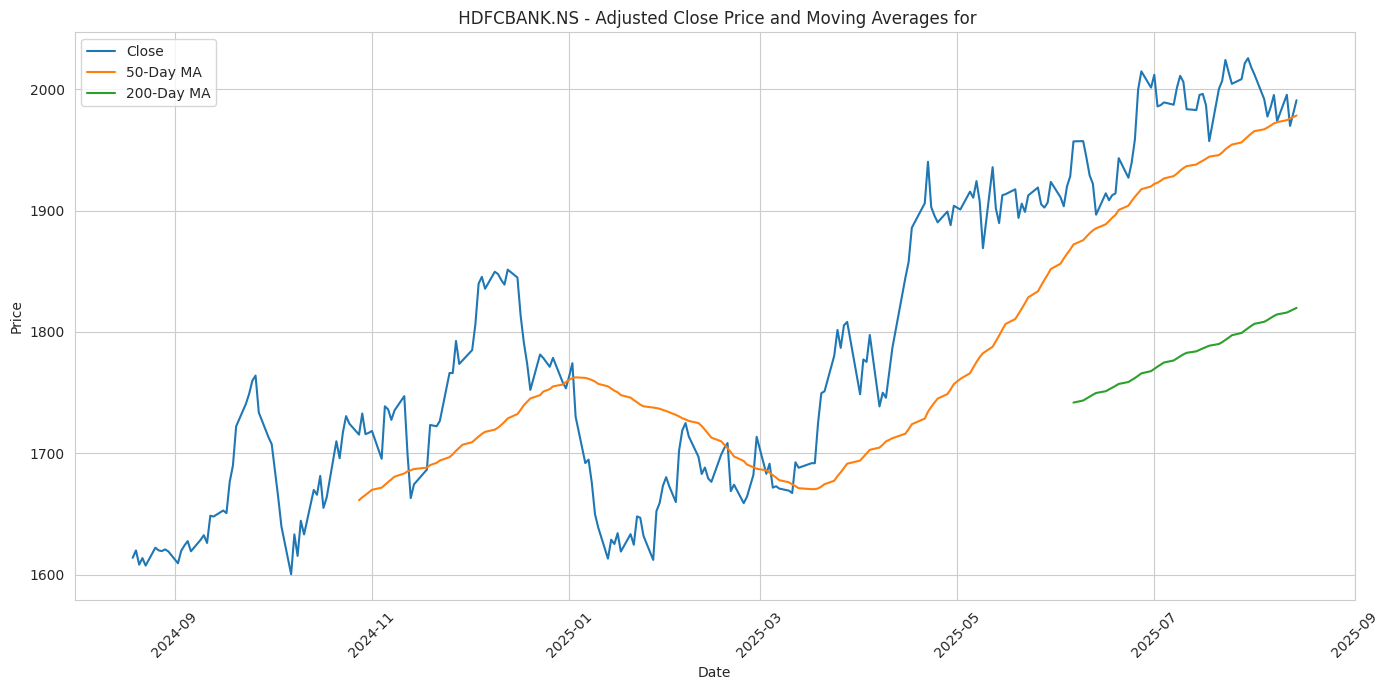

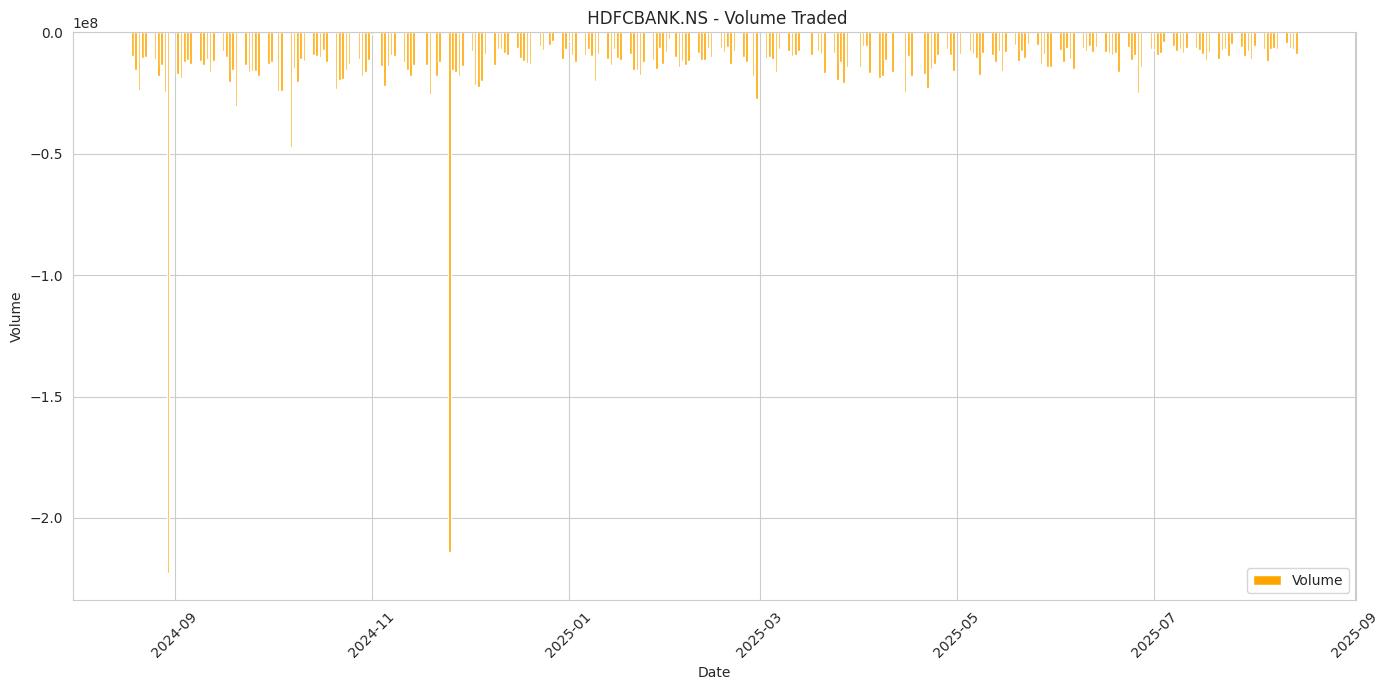

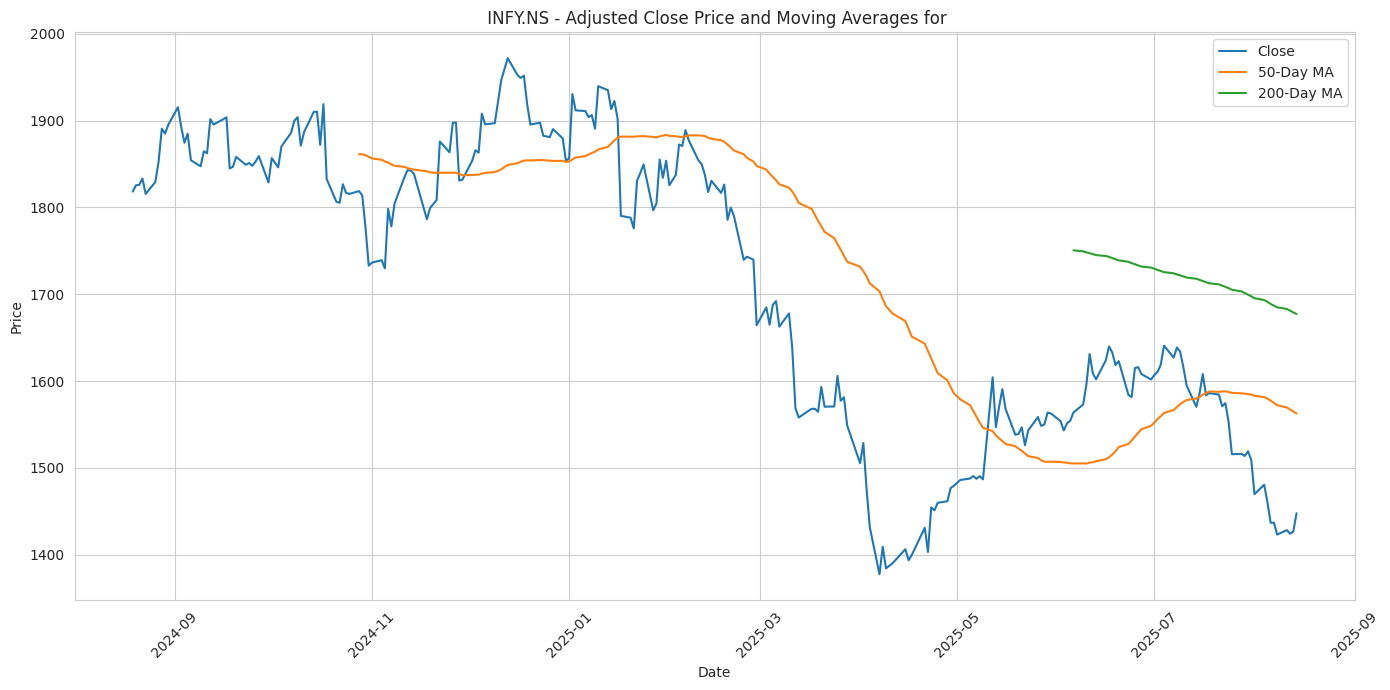

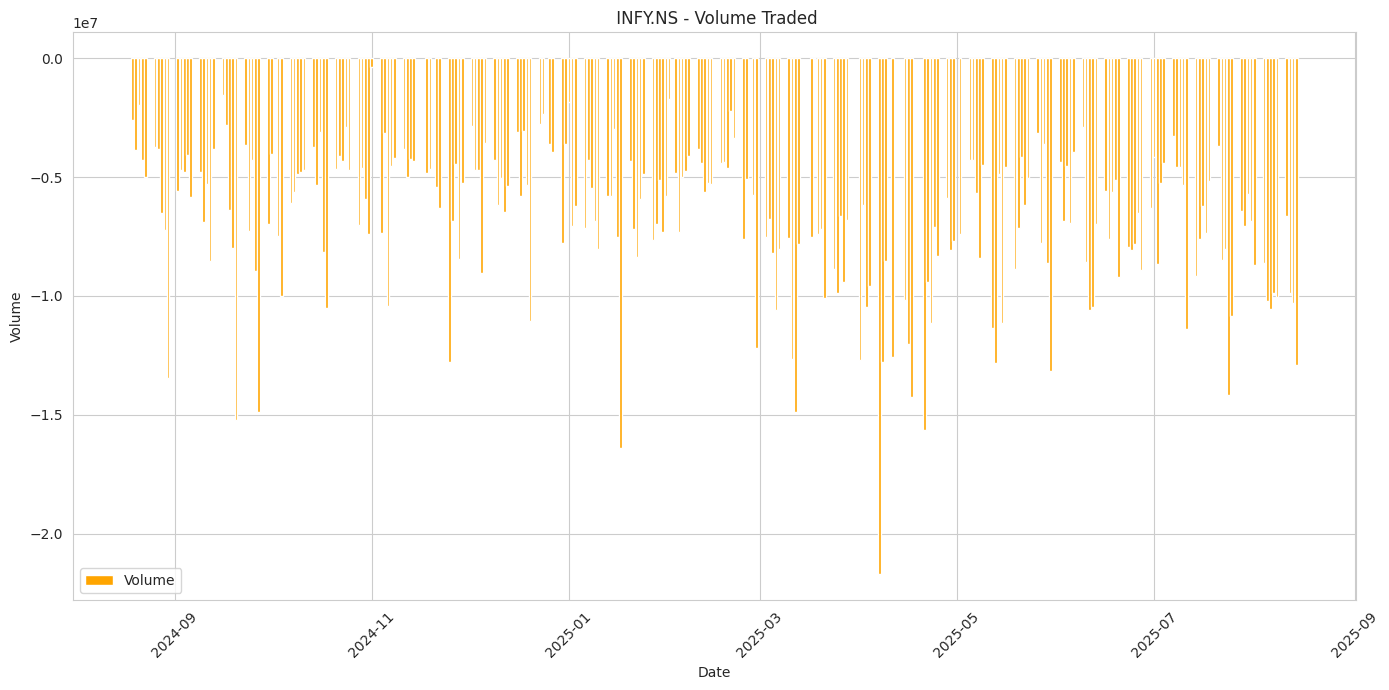

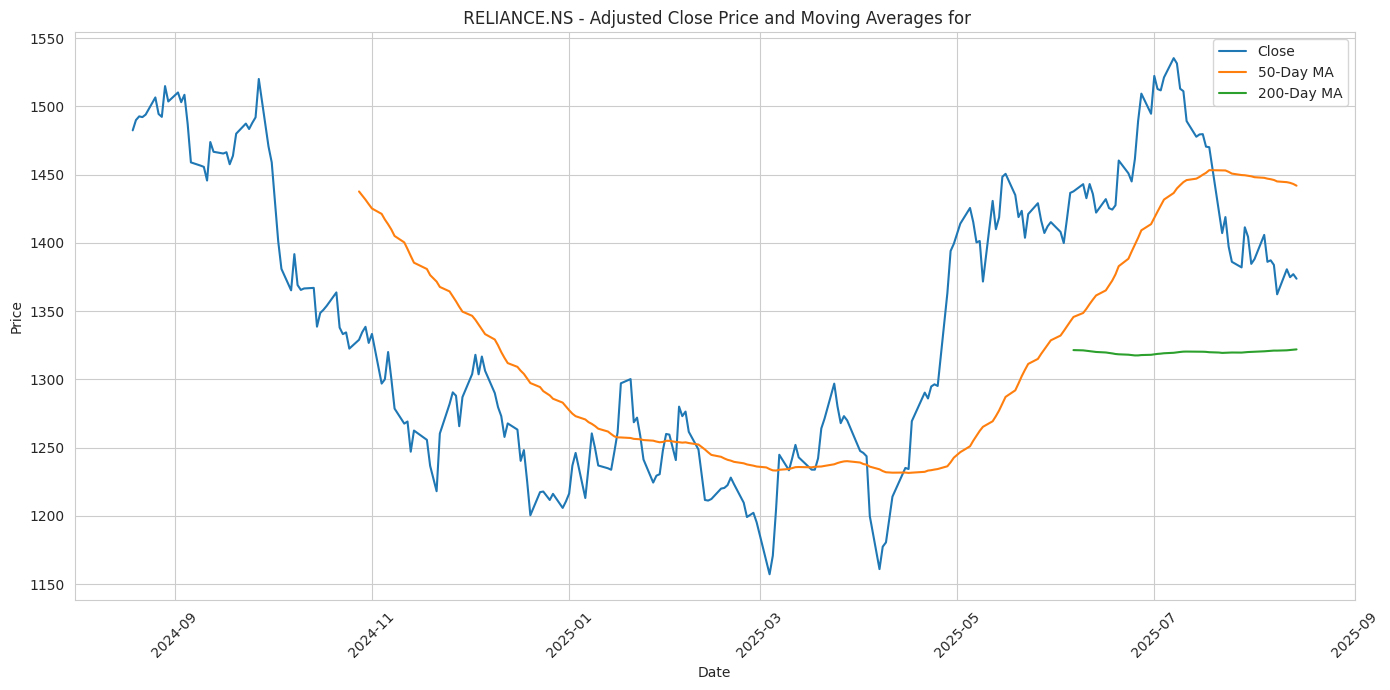

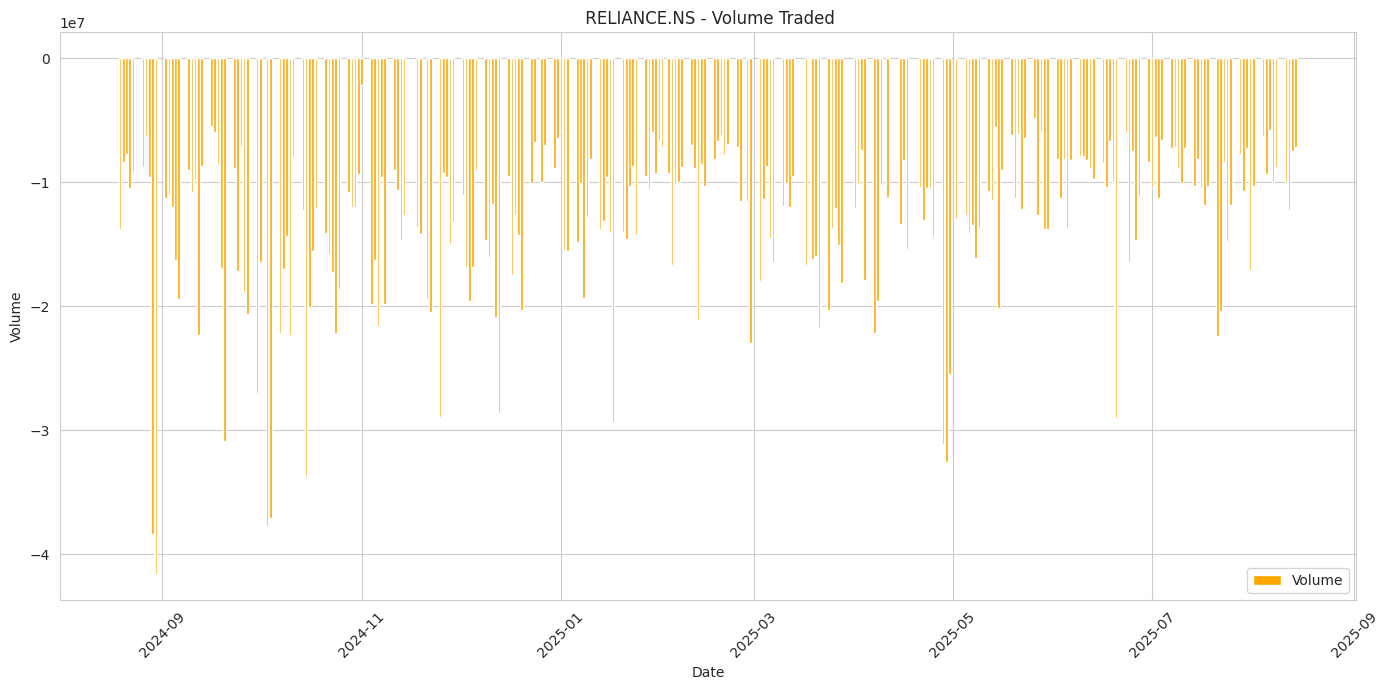

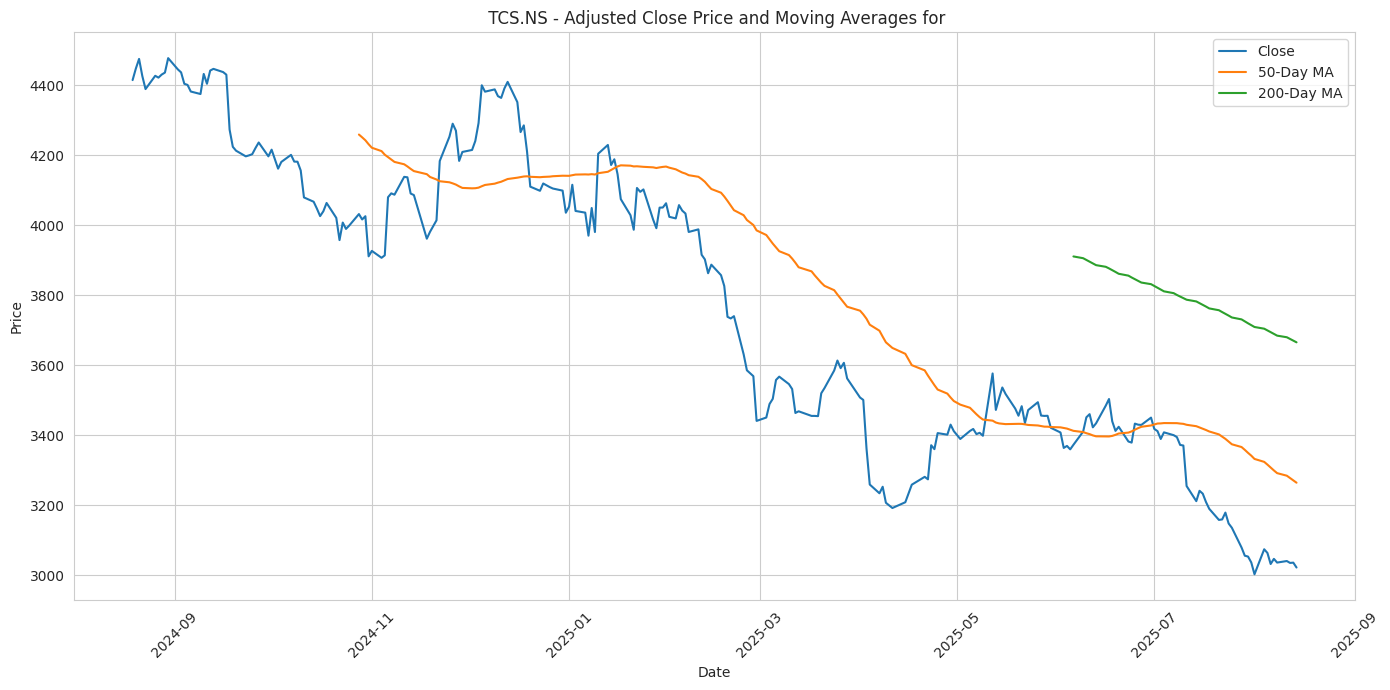

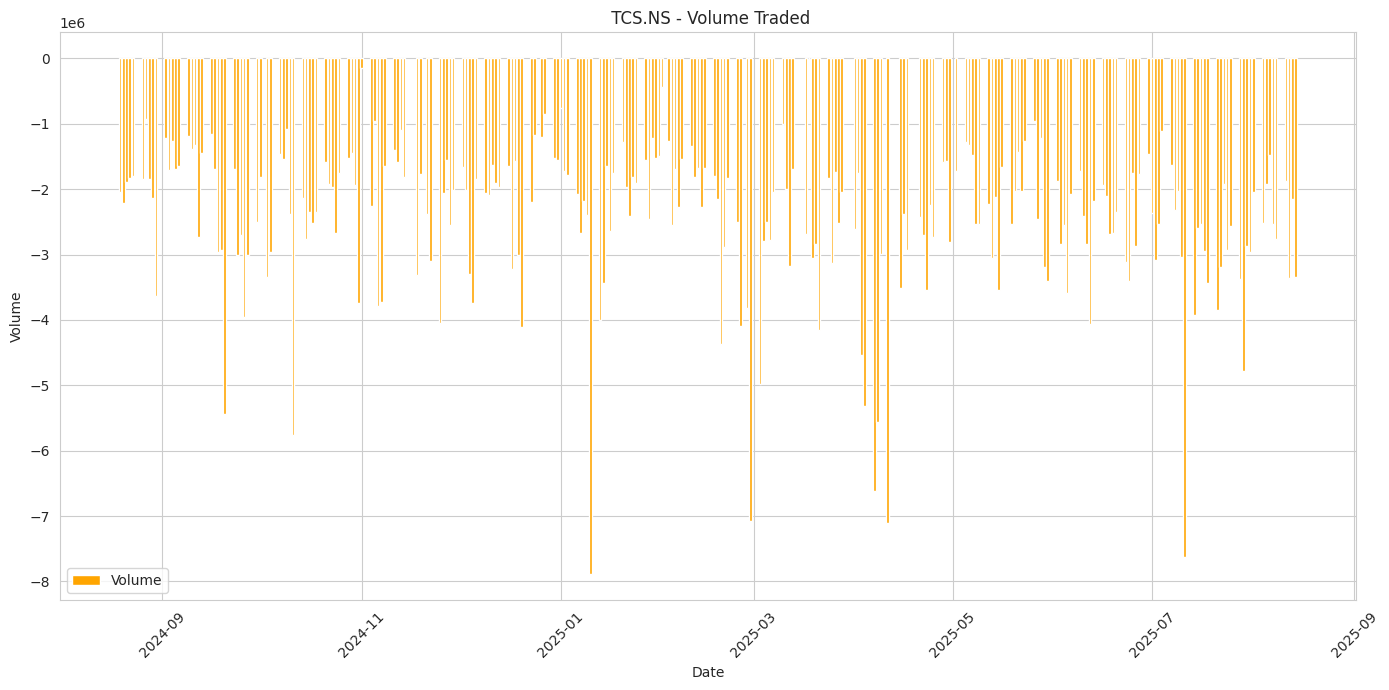

In [38]:
short_window = 50
long_window = 200

stock_data.set_index('Date', inplace=True)
unique_tickers = stock_data['Ticker'].unique()

for ticker in unique_tickers:
    ticker_data = stock_data[stock_data['Ticker'] == ticker].copy()
    ticker_data['50_MA'] = ticker_data['Close'].rolling(window=short_window).mean()
    ticker_data['200_MA'] = ticker_data['Close'].rolling(window=long_window).mean()

    plt.figure(figsize=(14, 7))
    plt.plot(ticker_data.index, ticker_data['Close'], label='Close')
    plt.plot(ticker_data.index, ticker_data['50_MA'], label=f'50-Day MA')
    plt.plot(ticker_data.index, ticker_data['200_MA'], label=f'200-Day MA')
    plt.title(f' {ticker} - Adjusted Close Price and Moving Averages for')
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(14, 7))
    plt.bar(ticker_data.index, ticker_data['Close'] - ticker_data['Volume'], label='Volume', color='Orange')
    plt.title(f' {ticker} - Volume Traded')
    plt.xlabel('Date')
    plt.ylabel('Volume')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

2. Graphiques : Adjusted Close Price and Moving Averages & Volume Traded

Ce que les graphiques montrent : Pour chaque action individuellement, vous avez deux graphiques :
Le premier graphique montre le prix de clôture ajusté (Close) et deux moyennes mobiles : la moyenne mobile sur 50 jours (50-Day MA) et la moyenne mobile sur 200 jours (200-Day MA).
Le second graphique est un graphique à barres montrant le volume traded (Volume) pour chaque jour de bourse. Note : Il semble y avoir une erreur dans le code de ce second graphique (ticker_data['Close'] - ticker_data['Volume']) qui affiche des valeurs négatives et ne représente pas le volume réel. Le volume devrait être une valeur positive.

**Interprétation des graphiques des moyennes mobiles** :

Identification des tendances : Les moyennes mobiles aident à confirmer les tendances. Lorsque le prix est au-dessus des moyennes mobiles, cela suggère une tendance haussière, et inversement.
Support et résistance : Les moyennes mobiles peuvent agir comme des niveaux dynamiques de support (si le prix rebondit dessus lors d'une baisse) ou de résistance (si le prix a du mal à dépasser lors d'une hausse).
Signaux de croisement : L'analyse des croisements de moyennes mobiles est une stratégie de trading courante. Un "golden cross" (50-Day MA croisant au-dessus de 200-Day MA) est souvent vu comme un signal d'achat potentiel, indiquant qu'une tendance à court terme devient plus forte qu'une tendance à long terme. Un "death cross" (50-Day MA croisant en dessous de 200-Day MA) est vu comme un signal de vente potentiel. Observez ces croisements sur les graphiques pour chaque action. Par exemple, sur le graphique d'INFY.NS, vous pouvez voir la 50-Day MA passer en dessous de la 200-Day MA, ce qui pourrait être interprété comme un signal baissier.

Retard : Les moyennes mobiles sont des indicateurs retardés, car elles sont basées sur des données passées.

**Interprétation potentielle du graphique de Volume (en supposant qu'il soit corrigé pour afficher le volume réel)** :

Confirmation des mouvements de prix : Un volume élevé accompagnant une forte hausse ou baisse de prix peut confirmer la force du mouvement. Un faible volume lors d'un mouvement important peut indiquer une faiblesse du mouvement.
Identifier les périodes d'intérêt : Les pics de volume peuvent indiquer des périodes d'intérêt accrues pour l'action, souvent autour d'annonces importantes ou d'événements de marché.
Signaux d'inversion potentiels : Parfois, une divergence entre le prix et le volume peut suggérer une potentielle inversion de tendance. Par exemple, si le prix atteint un nouveau sommet mais le volume est en baisse, cela pourrait indiquer que la force derrière la hausse diminue.

Voyons maintenant la distribution des rendements quotidiens de ces actions :



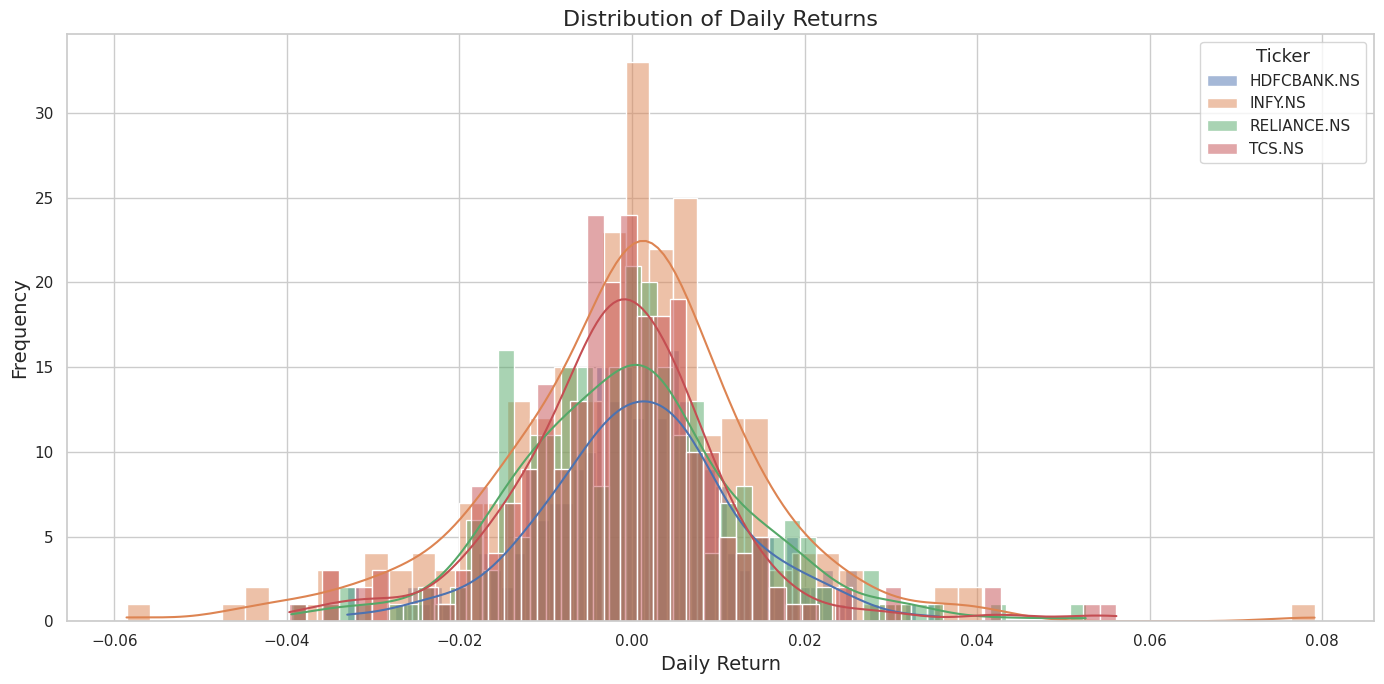

In [41]:
stock_data['Daily_Return'] = stock_data.groupby('Ticker')['Close'].pct_change()
plt.figure(figsize=(14, 7))
sns.set(style='whitegrid')
for ticker in unique_tickers:
    ticker_data = stock_data[stock_data['Ticker'] == ticker]
    sns.histplot(ticker_data['Daily_Return'].dropna(), bins=50, kde=True, label=ticker, alpha=0.5)
plt.title('Distribution of Daily Returns', fontsize=16)
plt.xlabel('Daily Return', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.legend(title='Ticker', title_fontsize= '13', fontsize = '11')
plt.grid(True)
plt.tight_layout()
plt.show()

3. Graphique : Distribution of Daily Returns

Ce que le graphique montre : Cet histogramme superpose la distribution des rendements quotidiens (la variation en pourcentage du prix de clôture d'un jour à l'autre) pour chaque action. La courbe lisse superposée est une estimation de la densité de probabilité (KDE - Kernel Density Estimate), qui aide à visualiser la forme de la distribution.

**Interprétation :**

Volatilité relative : La largeur de la distribution indique la volatilité de l'action. Une distribution plus large et plus étalée (comme celle d'INFY.NS ou TCS.NS) suggère une volatilité plus élevée, ce qui signifie que les prix ont tendance à fluctuer davantage d'un jour à l'autre. Une distribution plus étroite (comme celle de HDFCBANK.NS) indique une volatilité plus faible.
Rendement moyen : Le pic de la distribution (ou la moyenne) indique le rendement quotidien moyen. Si le pic est proche de zéro, cela signifie que les rendements quotidiens moyens sont faibles. Si le pic est décalé vers la droite (valeurs positives), le rendement quotidien moyen est positif, et s'il est décalé vers la gauche (valeurs négatives), le rendement quotidien moyen est négatif. Dans votre cas, les pics sont tous assez proches de zéro, ce qui est typique pour les rendements quotidiens sur une période d'un an.
Skewness (Asymétrie) : La forme de la distribution peut être asymétrique. Une asymétrie positive signifie qu'il y a une "longue queue" sur le côté droit (plus de grands rendements positifs extrêmes que de grands rendements négatifs extrêmes). Une asymétrie négative signifie l'inverse.
Kurtosis (Aplatissement) : La "épaisseur" des queues et la "hauteur" du pic indiquent le kurtosis. Un kurtosis élevé (distribution leptokurtique, avec un pic plus haut et des queues plus épaisses) signifie qu'il y a une probabilité plus élevée de rendements extrêmes (positifs ou négatifs) par rapport à une distribution normale. Cela est souvent observé dans les données boursières, indiquant un risque de "black swan" (événements rares et extrêmes).

Voyons maintenant s’il existe une corrélation entre tous ces stocks :



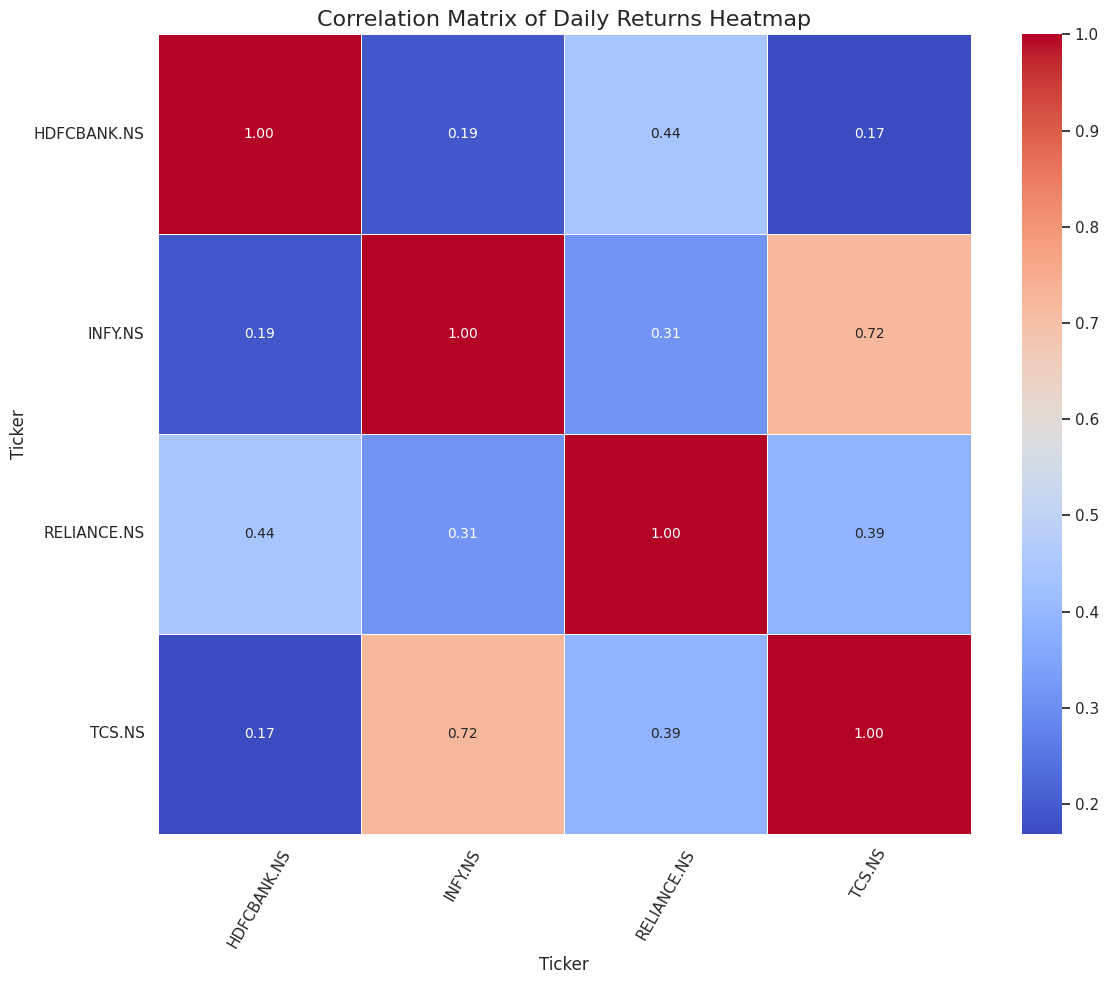

In [43]:
Daily_Return = stock_data.pivot_table(index='Date', columns='Ticker', values='Daily_Return')
correlation_matrix = Daily_Return.corr()

plt.figure(figsize=(12, 10))
sns.set(style='whitegrid')


sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=0.5, fmt='0.2f', annot_kws={"size":10})
plt.title('Correlation Matrix of Daily Returns Heatmap', fontsize=16)
plt.xticks(rotation=60)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

4. Graphique : Correlation Matrix of Daily Returns Heatmap

Ce que le graphique montre : Cette heatmap affiche la matrice de corrélation des rendements quotidiens des quatre actions. Chaque cellule de la matrice contient un nombre (le coefficient de corrélation, allant de -1 à +1) et une couleur qui représente la force et la direction de la corrélation entre les rendements de deux actions. Le long de la diagonale, la corrélation d'une action avec elle-même est toujours de 1.

**Interprétation :**

Corrélation positive : Un coefficient positif (couleurs chaudes, allant vers le rouge) indique que lorsque les rendements d'une action augmentent, les rendements de l'autre action ont tendance à augmenter également. Une corrélation proche de 1 signifie un mouvement très similaire. Par exemple, INFY.NS et TCS.NS ont une forte corrélation positive (0.72), ce qui n'est pas surprenant car ce sont deux grandes entreprises technologiques.

Corrélation négative : Un coefficient négatif (couleurs froides, allant vers le bleu) indique que lorsque les rendements d'une action augmentent, les rendements de l'autre action ont tendance à diminuer. Une corrélation proche de -1 signifie un mouvement très opposé.
Dans votre matrice, il n'y a pas de corrélations fortement négatives.
Faible corrélation : Un coefficient proche de 0 (couleurs neutres, comme le blanc ou le gris clair) indique une faible relation linéaire entre les rendements.

Diversification du portefeuille : Pour la construction de portefeuille, des actions faiblement corrélées ou négativement corrélées sont souhaitables car elles aident à réduire le risque global du portefeuille. Si les actifs ne bougent pas parfaitement ensemble, les pertes dans un actif peuvent être partiellement compensées par des gains dans un autre. Votre heatmap montre des corrélations positives entre les actions, ce qui est courant pour les actions d'un même marché, mais les niveaux de corrélation varient, offrant des opportunités de diversification (par exemple, la corrélation entre HDFCBANK.NS et TCS.NS est plus faible, autour de 0.17).

Calculons les rendements attendus et la volatilité pour chaque action :

In [44]:
import numpy as np

excepted_returns = Daily_Return.mean() * 252
volatility = Daily_Return.std() * np.sqrt(252)

stock_stats = pd.DataFrame({'Excepted_Returns': excepted_returns, 'Volatility': volatility})
print(stock_stats)

             Excepted_Returns  Volatility
Ticker                                   
HDFCBANK.NS          0.229435    0.178497
INFY.NS             -0.201426    0.245537
RELIANCE.NS         -0.055402    0.210208
TCS.NS              -0.364710    0.200151


5. Résultats : Excepted Returns and Volatility

Ce que les résultats montrent : Ce tableau affiche le rendement annuel attendu (Excepted_Returns) et la volatilité annualisée (Volatility) pour chaque action. Le rendement attendu est la moyenne des rendements quotidiens extrapolée sur une année, et la volatilité annualisée est une mesure du risque basé sur l'écart type des rendements quotidiens.

**Interprétation :**

Rendement vs Risque : En général, on s'attend à ce que les actifs avec un rendement attendu plus élevé présentent également une volatilité plus élevée (plus de risque).

Comparaison : Vous pouvez comparer le rendement attendu et la volatilité des différentes actions. Par exemple, HDFCBANK.NS a le rendement attendu le plus élevé (0.23) et une volatilité modérée (0.18), tandis que TCS.NS a le rendement attendu le plus bas (-0.36) mais une volatilité similaire à RELIANCE.NS. INFY.NS a un rendement attendu négatif (-0.20) et la volatilité la plus élevée (0.25).

Générons les portefeuilles aléatoires et traçons la frontière efficiente :



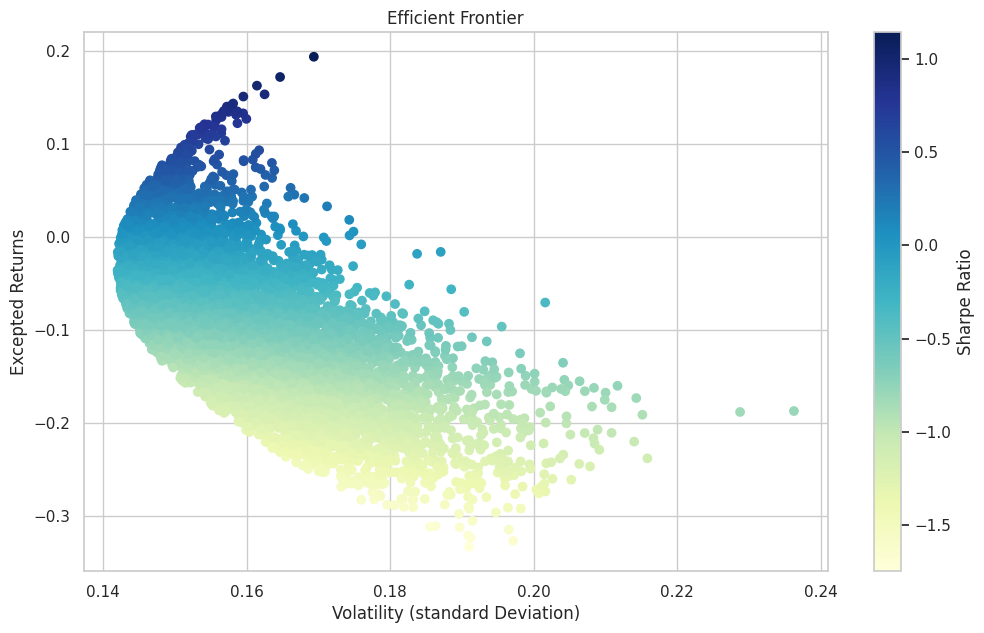

In [45]:
def portfolio_performance(weights, returns, cov_matrix):
  portfolio_return = np.dot(weights, returns)
  portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
  return portfolio_return, portfolio_volatility


num_portfolios = 10000

results = np.zeros((3, num_portfolios))
cov_matrix = Daily_Return.cov() * 252

np.random.seed(42)

for i in range(num_portfolios):
  weights = np.random.random(len(unique_tickers))
  weights /= np.sum(weights)
  portfolio_return, portfolio_volatility = portfolio_performance(weights, excepted_returns, cov_matrix)
  results[0, i] = portfolio_return
  results[1, i] = portfolio_volatility
  results[2, i] = portfolio_return / portfolio_volatility

plt.figure(figsize=(12, 7))
plt.scatter(results[1, :], results[0, :], c=results[2, :], cmap='YlGnBu', marker='o')
plt.xlabel('Volatility (standard Deviation)')
plt.ylabel('Excepted Returns')
plt.title('Efficient Frontier')
plt.colorbar(label='Sharpe Ratio')
plt.grid(True)
plt.show()

6. Graphique : Efficient Frontier

Ce que le graphique montre : Ce nuage de points représente des milliers de portefeuilles aléatoires construits en combinant les quatre actions avec différentes pondérations. L'axe des x représente la volatilité (risque) du portefeuille, et l'axe des y représente le rendement attendu du portefeuille. La couleur des points indique le ratio de Sharpe du portefeuille (une mesure du rendement par unité de risque), allant du jaune (faible) au bleu foncé (élevé). La "frontière efficiente" est la courbe supérieure de ce nuage de points, représentant les portefeuilles offrant le meilleur compromis risque-rendement.

**Interprétation :**

Compromis Risque-Rendement : Le graphique illustre clairement la relation entre le risque et le rendement. En général, pour obtenir un rendement attendu plus élevé, il faut accepter un niveau de volatilité plus élevé.
Portefeuilles inefficients : Les points situés en dessous de la frontière efficiente représentent des portefeuilles inefficients, car il existe d'autres portefeuilles avec le même niveau de risque qui offrent un rendement attendu plus élevé, ou avec le même rendement attendu qui présentent un risque plus faible.

Frontière efficiente : La courbe supérieure représente les portefeuilles optimaux. Un investisseur rationnel choisirait un portefeuille sur cette frontière en fonction de son appétit pour le risque.
Ratio de Sharpe : La coloration des points met en évidence les portefeuilles ayant un ratio de Sharpe plus élevé (couleurs plus foncées), qui sont considérés comme offrant un meilleur rendement ajusté au risque. Le portefeuille avec le ratio de Sharpe maximal se situe sur la frontière efficiente et représente le portefeuille optimal dans le cadre du modèle de Markowitz.

Voici comment identifier le portefeuille avec le ratio de Sharpe maximal :

In [52]:
max_sharpe_idx = np.argmax(results[2, :])
max_sharpe_return = results [0, max_sharpe_idx]
max_sharpe_volatility = results [1, max_sharpe_idx]
max_sharpe_ratio = results [2, max_sharpe_idx]

max_sharpe_return , max_sharpe_volatility, max_sharpe_ratio

(np.float64(0.19334326945603866),
 np.float64(0.16934779465549285),
 np.float64(1.141693459010554))

7. Résultats : Maximum Sharpe Ratio, Expected Return, Volatility
Ce que les résultats montrent : Ces chiffres vous donnent les valeurs spécifiques du ratio de Sharpe maximal trouvé parmi les portefeuilles aléatoires générés, ainsi que le rendement attendu et la volatilité du portefeuille qui a atteint ce ratio maximal.

**Interprétation :**

Ce portefeuille est, selon votre analyse, le portefeuille le plus "efficace" en termes de rendement par unité de risque sur la période étudiée. Le rendement attendu de ce portefeuille (environ 0.19) est le rendement que vous pourriez espérer en moyenne, compte tenu de son niveau de volatilité (environ 0.17). Le ratio de Sharpe (environ 1.14) quantifie ce rapport rendement/risque. Un ratio de Sharpe plus élevé est généralement préférable.

Ensuite, identifions les pondérations des actions du portefeuille qui génèrent le ratio de Sharpe maximal :

In [54]:
max_sharpe_weights = np.zeros(len(unique_tickers))
for i in range(num_portfolios):
  weights = np.random.random(len(unique_tickers))
  weights /= np.sum(weights)
  portfolio_return, portfolio_volatility = portfolio_performance(weights, excepted_returns, cov_matrix)

  if results[2, i] == max_sharpe_ratio:
    max_sharpe_weights = weights
    break

portfolio_weights_df = pd.DataFrame({'Ticker': unique_tickers, 'Weight': max_sharpe_weights})
portfolio_weights_df

,Ticker,Weight
0,HDFCBANK.NS,0.011916
1,INFY.NS,0.366496
2,RELIANCE.NS,0.349356
3,TCS.NS,0.272233


8. Résultats : Portfolio Weights

Ce que les résultats montrent : Ce tableau affiche les pondérations (pourcentages) que chaque action doit avoir dans le portefeuille pour atteindre le ratio de Sharpe maximal identifié précédemment.

**Interprétation :**

Ces pondérations sont les proportions de votre capital que vous devriez allouer à chaque action individuelle pour construire le portefeuille optimal selon cette analyse. Par exemple, pour ce portefeuille spécifique, vous devriez investir environ 1.2% dans HDFCBANK.NS, 36.6% dans INFY.NS, 34.9% dans RELIANCE.NS et 27.2% dans TCS.NS. Ces pondérations sont basées sur les données historiques et le modèle d'optimisation utilisé. Elles changeraient avec des données différentes ou un modèle différent.
En combinant les interprétations de tous ces graphiques et résultats, vous obtenez une vue d'ensemble de la performance individuelle des actions, de leurs relations et de la manière de les combiner pour construire un portefeuille qui optimise le compromis risque-rendement.